Usage of AI

AI was used to help with this assignment. I used AI for troubleshooting, finding suitable Python commands, and improving the structure and readability of the notebook. All code was reviewed, tested, and adjusted by me before submission.


In [ ]:
#Task 0

Part a:

Dataset i chose is Beijing Multi-Site Air Quality dataset. 

link: https://archive.ics.uci.edu/dataset/501/beijingmultisiteairqualitydata 

Part b:

This is a dataset containing hourly air pollution and weather data collected from 12 air quality monitoring stations in Beijing, China. 
It covers data from 2013 to 2017.

Variables in the dataset are: year, month, day, hour, PM2.5, PM10, SO2, NO2, CO, O3, temperature (TEMP), pressure (PRES), dew point (DEWP), rain, wind direction (wd), wind speed (WSPM), and station name.

The entire dataset contains 420 768 rows in total, so i chose to use only the data from the Wanshouxigong weather station. This lowers the total row count that i will use here to 35 064. 

In the course project, I could use this dataset to study how air pollution changes over time, compare pollution levels between stations. Furthermore, i could examine how weather variables such as temperature, wind speed, and rain are related to pollution levels.

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong,2013-03-01 00:00:00
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong,2013-03-01 01:00:00
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong,2013-03-01 02:00:00
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong,2013-03-01 03:00:00
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong,2013-03-01 04:00:00


Shape: (35064, 19)


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,34368.000000,34580.000000,34395.000000,34310.00000,33767.000000,33986.000000,35045.000000,35045.000000,35045.000000,35045.000000,35051.000000
mean,85.024136,112.223459,17.148603,55.52956,1370.395031,56.229904,13.784477,1011.511804,2.707442,0.064320,1.745314
std,85.975981,97.593210,23.940834,35.80805,1223.139114,57.082710,11.385156,10.570928,13.704139,0.796981,1.206355
min,3.000000,2.000000,0.285600,2.00000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,0.000000
25%,23.000000,39.000000,3.000000,28.00000,600.000000,8.000000,3.400000,1002.800000,-8.500000,0.000000,0.900000
50%,60.000000,91.000000,8.000000,49.00000,1000.000000,42.000000,14.800000,1011.000000,3.300000,0.000000,1.400000
75%,116.000000,154.000000,21.000000,77.00000,1700.000000,82.000000,23.500000,1020.000000,15.200000,0.000000,2.300000
max,999.000000,961.000000,411.000000,251.00000,9800.000000,358.000000,40.600000,1042.000000,28.500000,46.400000,13.200000


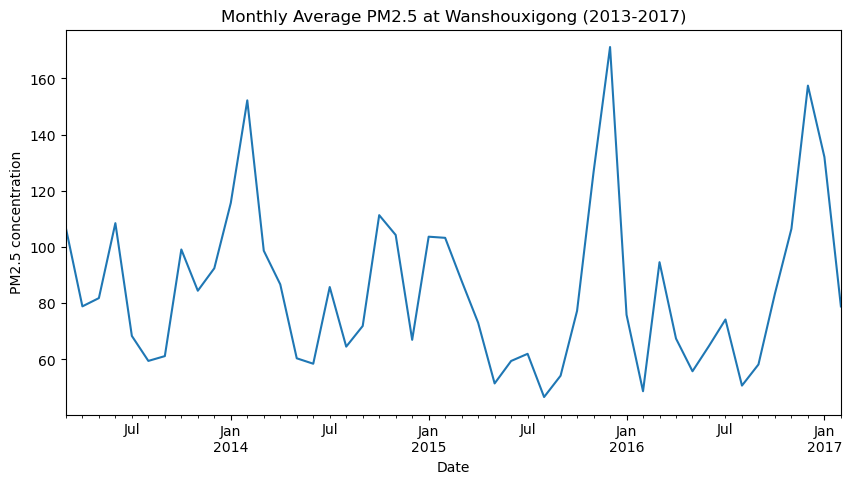

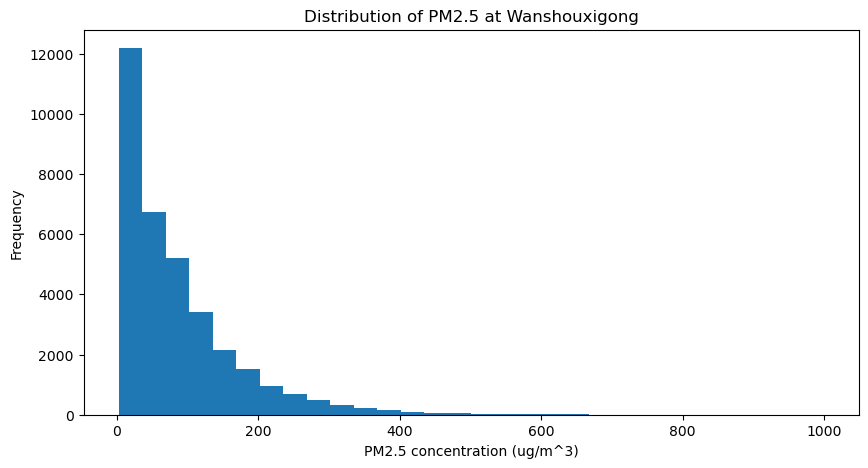

In [2]:
# Part c

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

#first 5 lines
df = pd.read_csv("PRSA_Data_Wanshouxigong_20130301-20170228.csv")


df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

display(df.head())
print("Shape:", df.shape)


# Summary statisctics of all numeric columns
numeric_columns = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

display(df[numeric_columns].describe())


# Visualization 1, a line chart of monthly average of PM2.5 levels.
monthly_pm25 = df.set_index("datetime")["PM2.5"].resample("ME").mean()

plt.figure(figsize=(10, 5))
monthly_pm25.plot()

plt.title("Monthly Average PM2.5 at Wanshouxigong (2013-2017)")
plt.xlabel("Date")
plt.ylabel("PM2.5 concentration")
plt.show()

# Visualization 2: a histogram of PM2.5 at the station.
plt.figure(figsize=(10, 5))
df["PM2.5"].dropna().plot(kind="hist", bins=30)

plt.title("Distribution of PM2.5 at Wanshouxigong")
plt.xlabel("PM2.5 concentration (ug/m^3)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#Task 1

In [1]:
from dotenv import load_dotenv
import os

load_dotenv(".env")

marketstack_api_key = os.getenv("MARKETSTACK_API_KEY")

if marketstack_api_key:
    print(marketstack_api_key[:5] + "...")
else:
    print("MARKETSTACK_API_KEY not found")


65c78...


In [ ]:
#Task 2

In [3]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display

load_dotenv(".env")

marketstack_api_key = os.getenv("MARKETSTACK_API_KEY")

# part a

url = "https://api.marketstack.com/v2/eod"

params = {
    "access_key": marketstack_api_key,
    "symbols": "META,AAPL,AMZN,NFLX,GOOG",
    "date_from": "2026-03-01",
    "date_to": "2026-03-31",
    "sort": "ASC",
    "limit": 1000
}

response = requests.get(url, params=params)
response.raise_for_status()

stock_json = response.json()

if "error" in stock_json:
    print(stock_json["error"])
else:
    print("Request successful")
    print("Rows returned:", len(stock_json["data"]))

# part b
stock_df = pd.DataFrame(stock_json["data"])

stock_df["date"] = pd.to_datetime(stock_df["date"]).dt.date

stock_df = stock_df.sort_values(["symbol", "date"]).reset_index(drop=True)

display(stock_df.head())

# part c
close_summary = stock_df.groupby("symbol")["close"].describe()
display(close_summary)

returns_df = stock_df.groupby("symbol").agg(
    first_close=("close", "first"),
    last_close=("close", "last")
).reset_index()

returns_df["return_percent"] = (
    (returns_df["last_close"] - returns_df["first_close"]) / returns_df["first_close"]
) * 100

returns_df = returns_df.sort_values("return_percent", ascending=False).reset_index(drop=True)

display(returns_df)

best_stock = returns_df.iloc[0]["symbol"]
best_return = returns_df.iloc[0]["return_percent"]

worst_stock = returns_df.iloc[-1]["symbol"]
worst_return = returns_df.iloc[-1]["return_percent"]

print(f"Best performer in March 2026: {best_stock} ({best_return:.2f}%)")
print(f"Worst performer in March 2026: {worst_stock} ({worst_return:.2f}%)")

Request successful
Rows returned: 110


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-06


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


,symbol,first_close,last_close,return_percent
0,AMZN,208.39,208.27,-0.057584
1,NFLX,97.09,96.15,-0.968174
2,AAPL,264.72,253.79,-4.128891
3,GOOG,306.36,286.86,-6.365061
4,META,653.56,572.13,-12.459453


Best performer in March 2026: AMZN (-0.06%)
Worst performer in March 2026: META (-12.46%)


In [4]:
# Task 3

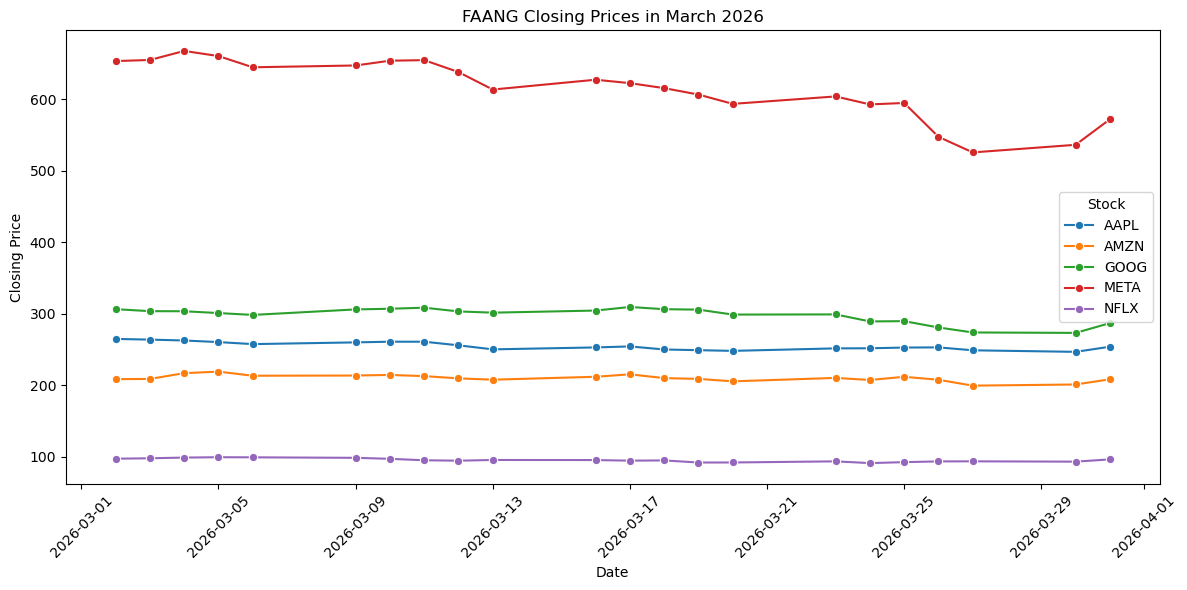

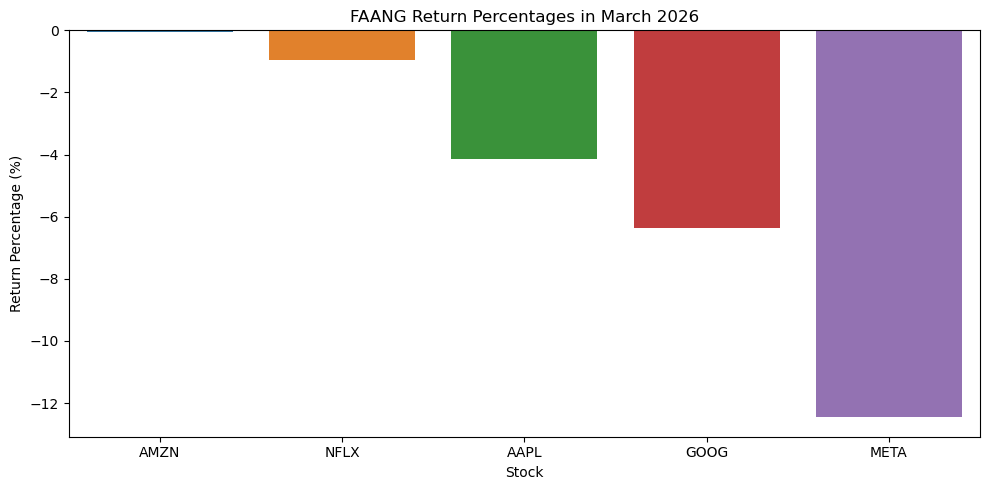

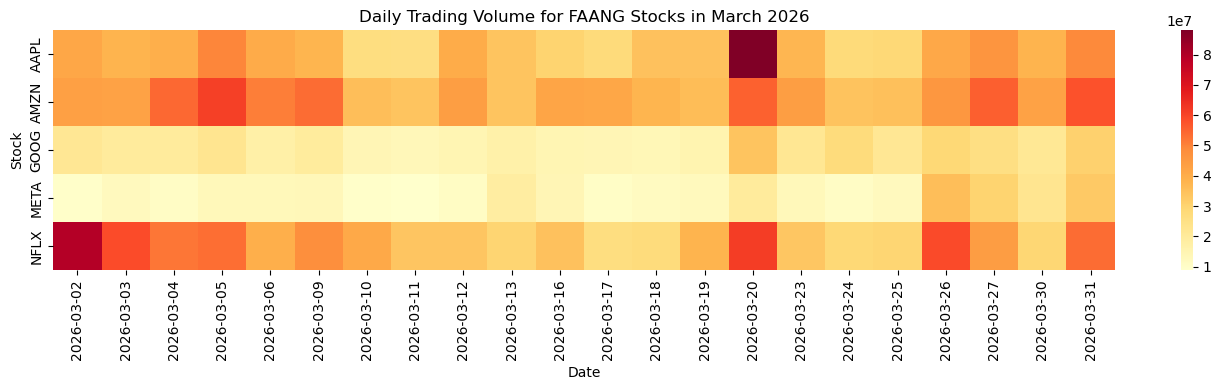

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


# part a

plt.figure(figsize=(12, 6))

sns.lineplot(data=stock_df, x="date", y="close", hue="symbol", marker="o")

plt.title("FAANG Closing Prices in March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend(title="Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# part b

plt.figure(figsize=(10, 5))

sns.barplot(data=returns_df, x="symbol", y="return_percent", hue="symbol", dodge=False, legend=False)

plt.title("FAANG Return Percentages in March 2026")
plt.xlabel("Stock")
plt.ylabel("Return Percentage (%)")
plt.tight_layout()
plt.show()


# part c

volume_pivot = stock_df.pivot(index="symbol", columns="date", values="volume")

plt.figure(figsize=(14, 4))

sns.heatmap(volume_pivot, cmap="YlOrRd")

plt.title("Daily Trading Volume for FAANG Stocks in March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.tight_layout()
plt.show()

In [ ]:
# Task 4

In [18]:
import os
import json
import pandas as pd
from IPython.display import display

os.makedirs("exports", exist_ok=True)

with open("exports/stockdata.json", "w", encoding="utf-8") as file:
    json.dump(stock_json, file, indent=4)

stock_df.to_csv("exports/stockdata.csv", index=False)

print("Files exported successfully.")

# Reload and verify

with open("exports/stockdata.json", "r", encoding="utf-8") as file:
    loaded_stock_json = json.load(file)

loaded_json_df = pd.DataFrame(loaded_stock_json["data"])
loaded_json_df["date"] = pd.to_datetime(loaded_json_df["date"]).dt.date
loaded_json_df = loaded_json_df.sort_values(["symbol", "date"]).reset_index(drop=True)

loaded_csv_df = pd.read_csv("exports/stockdata.csv")
loaded_csv_df["date"] = pd.to_datetime(loaded_csv_df["date"]).dt.date
loaded_csv_df = loaded_csv_df.sort_values(["symbol", "date"]).reset_index(drop=True)

display(loaded_json_df.head())
display(loaded_csv_df.head())

print("JSON row count matches original:", len(loaded_json_df) == len(stock_df))
print("CSV row count matches original:", len(loaded_csv_df) == len(stock_df))


Files exported successfully.


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-06


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-06


JSON row count matches original: True
CSV row count matches original: True


In [ ]:
# Task 5

In [20]:
import sqlite3
import pandas as pd
from IPython.display import display

conn = sqlite3.connect("northwind.db")

# part a

tables_df = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name
""", conn)

display(tables_df)

# part b

products_above_30_df = pd.read_sql_query("""
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30
ORDER BY UnitPrice DESC
""", conn)

display(products_above_30_df)

# part c

germany_orders_df = pd.read_sql_query("""
SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c
    ON o.CustomerID = c.CustomerID
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
ORDER BY o.OrderDate
""", conn)

display(germany_orders_df)

,name
0,Categories
1,CustomerCustomerDemo
2,CustomerDemographics
3,Customers
4,EmployeeTerritories
5,Employees
6,Order Details
7,Orders
8,Products
9,Regions


,ProductName,UnitPrice,UnitsInStock
0,Côte de Blaye,263.50,17
1,Thüringer Rostbratwurst,123.79,0
2,Mishi Kobe Niku,97.00,29
3,Sir Rodney's Marmalade,81.00,40
4,Carnarvon Tigers,62.50,42
5,Raclette Courdavault,55.00,79
6,Manjimup Dried Apples,53.00,20
7,Tarte au sucre,49.30,17
8,Ipoh Coffee,46.00,17
9,Rössle Sauerkraut,45.60,26


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Que Delícia,25111,2012-07-16 00:26:10,Germany,190.0
1,Que Delícia,25111,2012-07-16 00:26:10,Germany,220.0
2,Que Delícia,25111,2012-07-16 00:26:10,Germany,213.5
3,Que Delícia,25111,2012-07-16 00:26:10,Germany,1175.0
4,Que Delícia,25111,2012-07-16 00:26:10,Germany,1067.0
...,...,...,...,...,...
80668,Princesa Isabel Vinhos,17105,2023-10-23 06:17:48,Germany,360.0
80669,Princesa Isabel Vinhos,17105,2023-10-23 06:17:48,Germany,378.0
80670,Princesa Isabel Vinhos,17105,2023-10-23 06:17:48,Germany,182.0
80671,White Clover Markets,18298,2023-10-24 02:51:15,Germany,110.4


In [ ]:
# Task 6

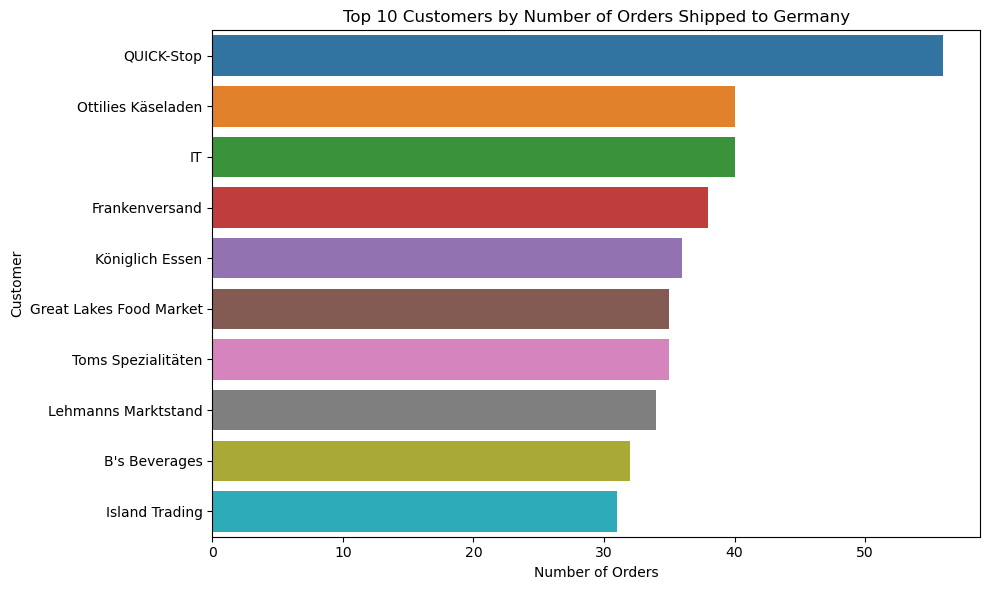

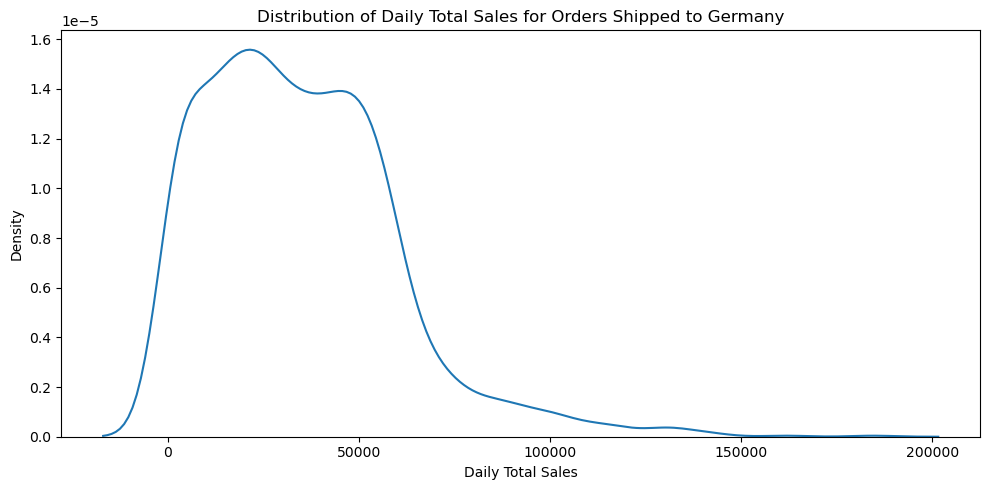

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


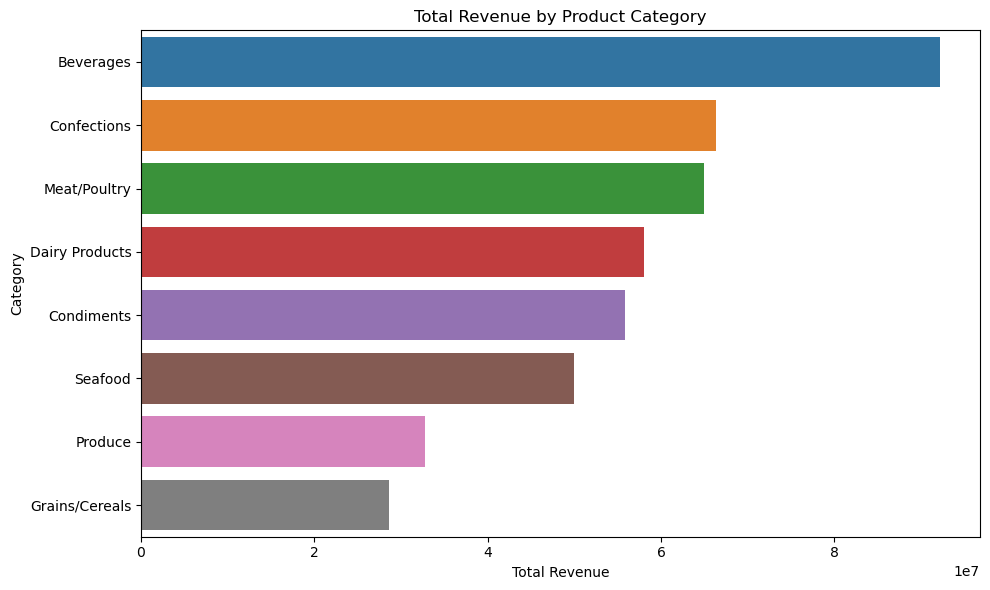

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# part a

top_customers_df = (
    germany_orders_df.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="OrderCount")
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_customers_df, x="OrderCount", y="CompanyName", hue="CompanyName", dodge=False, legend=False)

plt.title("Top 10 Customers by Number of Orders Shipped to Germany")
plt.xlabel("Number of Orders")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

# part b

germany_orders_df["OrderDate"] = pd.to_datetime(germany_orders_df["OrderDate"], format="mixed")

daily_sales_df = (
    germany_orders_df.groupby(germany_orders_df["OrderDate"].dt.date)["LineTotal"]
    .sum()
    .reset_index(name="DailyTotalSales")
)

plt.figure(figsize=(10, 5))
sns.kdeplot(data=daily_sales_df, x="DailyTotalSales")

plt.title("Distribution of Daily Total Sales for Orders Shipped to Germany")
plt.xlabel("Daily Total Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# part c

category_revenue_df = pd.read_sql_query("""
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p
    ON od.ProductID = p.ProductID
JOIN Categories cat
    ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC
""", conn)

display(category_revenue_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=category_revenue_df, x="TotalRevenue", y="CategoryName", hue="CategoryName", dodge=False, legend=False)

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


In [ ]:
# task 7

In [23]:
import time

# part a

products_df = pd.read_sql_query("SELECT * FROM Products", conn)
categories_df = pd.read_sql_query("SELECT * FROM Categories", conn)

display(products_df.head())
display(categories_df.head())

# part b

products_categories_df = pd.merge(products_df, categories_df, on="CategoryID", how="inner")

display(products_categories_df.head())

# part c

# SQL timing
start_sql = time.time()

sql_result_df = pd.read_sql_query("""
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p
    ON od.ProductID = p.ProductID
JOIN Categories cat
    ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC
""", conn)

sql_time = time.time() - start_sql

# Python timing
start_python = time.time()

order_details_df = pd.read_sql_query('SELECT * FROM "Order Details"', conn)
products_full_df = pd.read_sql_query("SELECT * FROM Products", conn)
categories_full_df = pd.read_sql_query("SELECT * FROM Categories", conn)

merged_df = pd.merge(order_details_df, products_full_df, on="ProductID", how="inner")
merged_df = pd.merge(merged_df, categories_full_df, on="CategoryID", how="inner")

merged_df["Revenue"] = merged_df["UnitPrice_x"] * merged_df["Quantity"]

python_result_df = (
    merged_df.groupby("CategoryName", as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Revenue": "TotalRevenue"})
    .sort_values("TotalRevenue", ascending=False)
    .reset_index(drop=True)
)

python_time = time.time() - start_python

display(sql_result_df)
display(python_result_df)

print(f"SQL execution time: {sql_time:.6f} seconds")
print(f"Python execution time: {python_time:.6f} seconds")

if sql_time < python_time:
    print("SQL was faster in this comparison.")
else:
    print("Python with pandas was faster in this comparison.")


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


SQL execution time: 3.143273 seconds
Python execution time: 5.942461 seconds
SQL was faster in this comparison.


In [24]:
conn.close()

In [ ]:
# task 8

In [25]:
# Original wide-format dataset
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

# Original long-format dataset
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

display(wide_data)
display(long_data)

# part a

wide_to_long_df = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

display(wide_data)
display(wide_to_long_df)

# part b

long_to_wide_df = long_data.pivot(index="month", columns="product", values="units_sold").reset_index()
long_to_wide_df.columns.name = None

display(long_data)
display(long_to_wide_df)

# part c

# Task 8c: convert both transformed datasets back to their original format

# Convert wide_to_long_df back to wide format
wide_restored_df = wide_to_long_df.pivot(index="store", columns="quarter", values="sales").reset_index()
wide_restored_df.columns.name = None
wide_restored_df = wide_restored_df[["store", "Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"]]

# Convert long_to_wide_df back to long format
long_restored_df = long_to_wide_df.melt(
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)

month_order = {"Jan": 1, "Feb": 2, "Mar": 3}
product_order = {"Laptop": 1, "Phone": 2}

long_restored_df["month_order"] = long_restored_df["month"].map(month_order)
long_restored_df["product_order"] = long_restored_df["product"].map(product_order)

long_restored_df = (
    long_restored_df.sort_values(["month_order", "product_order"])
    .drop(columns=["month_order", "product_order"])
    .reset_index(drop=True)
)

display(wide_data)
display(wide_restored_df)

display(long_data)
display(long_restored_df)


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130
